# Analiza wyników — GQA (Lista 12)

In [20]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
from IPython.display import display

warnings.filterwarnings('ignore')
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('./mlruns')

COLORS = {'MHA': '#2ecc71', 'GQA': '#3498db', 'MQA': '#e74c3c', 'DynamicGQA': '#e67e22'}
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

def load_exp(name):
    exp = mlflow.get_experiment_by_name(name)
    df = mlflow.search_runs(experiment_ids=[exp.experiment_id], output_format='pandas')
    df.columns = [
        'run_name' if c == 'tags.mlflow.runName'
        else c.replace('params.', '').replace('metrics.', '').replace('tags.', '')
        for c in df.columns
    ]
    df = df[df['status'] == 'FINISHED'].copy()
    for col in ['num_heads', 'num_groups', 'seed', 'num_params', 'max_length']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_imdb = load_exp('GQA_IMDB')
df_ins  = load_exp('GQA_InsectWingbeat')
print(f'IMDB ukończone runy:    {len(df_imdb)}')
print(f'InsectWingbeat ukończone: {len(df_ins)}')

IMDB ukończone runy:    67
InsectWingbeat ukończone: 54


---
## IMDB — Eksperyment 1: Siatka H×G

In [21]:
exp1 = df_imdb[df_imdb['run_name'].str.startswith('grid_')].copy()

grid = exp1.groupby(['num_heads', 'num_groups', 'attention_type']).agg(
    acc    = ('best_test_acc', 'mean'),
    ovft   = ('overfitting_gap', 'mean'),
    params = ('num_params', 'first'),
    inf_ms = ('inference_time_ms', 'mean'),
    avg_epoch_time_s = ('avg_epoch_time_s', 'mean'),
).reset_index()

display(grid[['num_heads','num_groups','attention_type','acc','ovft','params','inf_ms', 'avg_epoch_time_s']]
        .sort_values('acc', ascending=False).reset_index(drop=True))

,num_heads,num_groups,attention_type,acc,ovft,params,inf_ms,avg_epoch_time_s
0,4,1,MQA,0.838480,0.089480,1840706,21.591600,35.096631
1,2,2,MHA,0.837920,0.094333,1914434,15.068653,26.831415
2,1,1,MHA,0.837080,0.091480,1914434,13.334169,22.803414
3,8,2,GQA,0.836920,0.093827,1840706,35.733225,60.202923
4,8,1,MQA,0.836507,0.089387,1828418,37.605774,61.993778
5,4,2,GQA,0.836387,0.096547,1865282,22.762663,38.781595
6,2,1,MQA,0.835960,0.093293,1865282,14.577724,25.665314
7,4,4,MHA,0.834827,0.103133,1914434,23.104821,40.866590
8,8,4,GQA,0.833480,0.105640,1865282,34.001247,55.894929
9,8,8,MHA,0.832693,0.112053,1914434,35.057973,61.985799


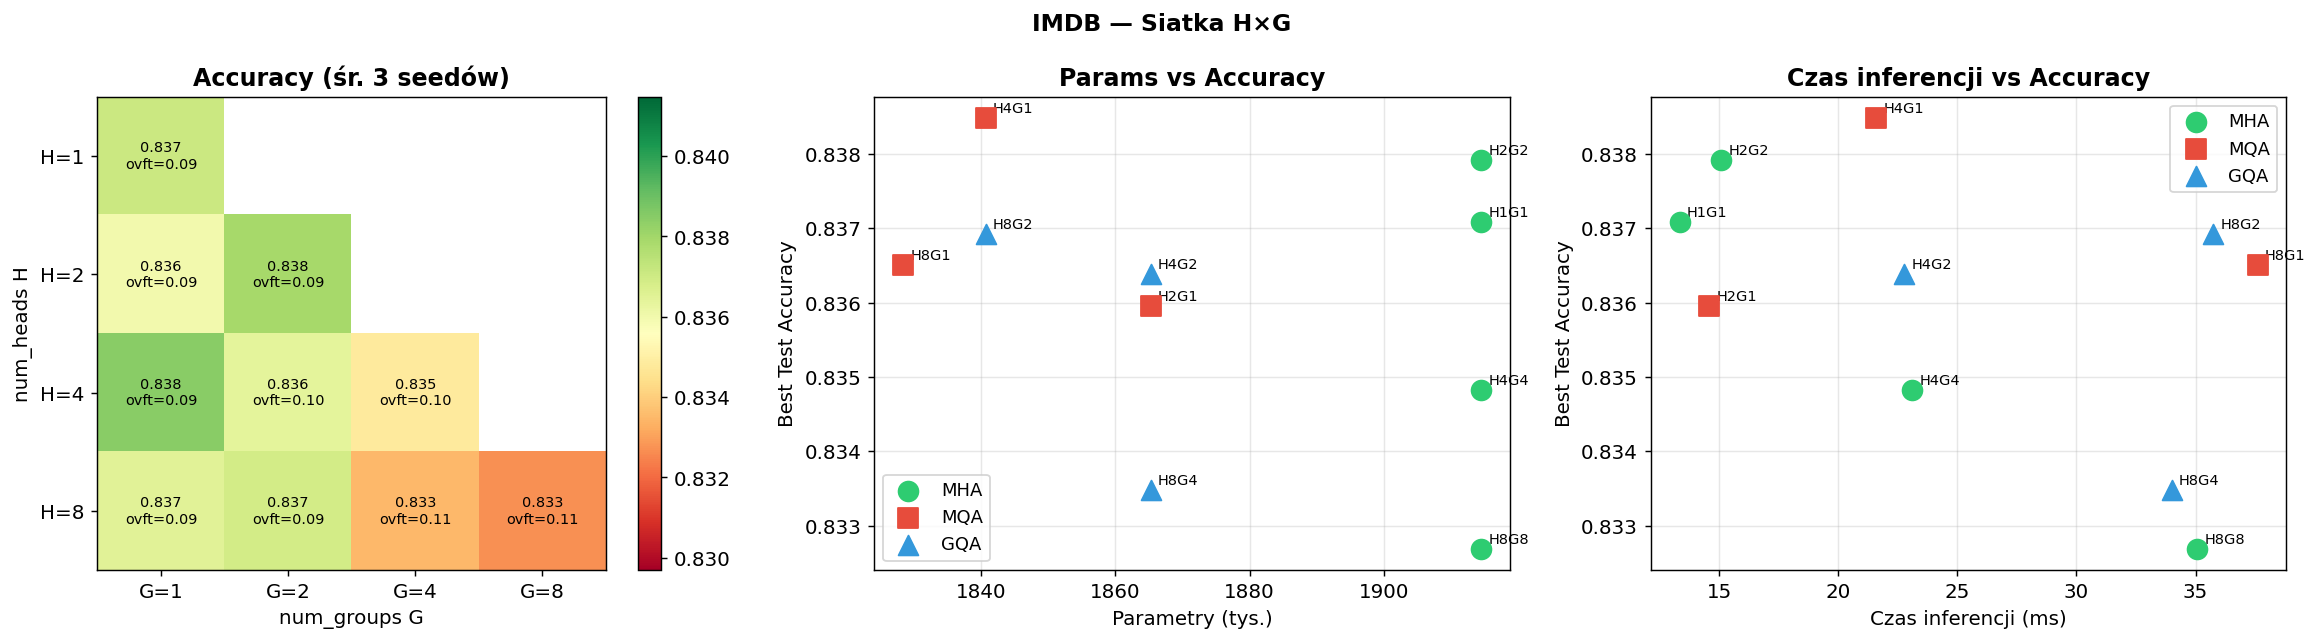

,num_heads,num_groups,attention_type,acc,ovft,params,inf_ms,avg_epoch_time_s
0,4,1,MQA,0.838480,0.089480,1840706,21.591600,35.096631
1,2,2,MHA,0.837920,0.094333,1914434,15.068653,26.831415
2,1,1,MHA,0.837080,0.091480,1914434,13.334169,22.803414
3,8,2,GQA,0.836920,0.093827,1840706,35.733225,60.202923
4,8,1,MQA,0.836507,0.089387,1828418,37.605774,61.993778
5,4,2,GQA,0.836387,0.096547,1865282,22.762663,38.781595
6,2,1,MQA,0.835960,0.093293,1865282,14.577724,25.665314
7,4,4,MHA,0.834827,0.103133,1914434,23.104821,40.866590
8,8,4,GQA,0.833480,0.105640,1865282,34.001247,55.894929
9,8,8,MHA,0.832693,0.112053,1914434,35.057973,61.985799


In [22]:
H_vals = sorted(exp1['num_heads'].dropna().unique().astype(int))
G_vals = sorted(exp1['num_groups'].dropna().unique().astype(int))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Heatmapa accuracy ---
mat_acc  = np.full((len(H_vals), len(G_vals)), np.nan)
mat_ovft = np.full((len(H_vals), len(G_vals)), np.nan)

for _, row in grid.iterrows():
    i = H_vals.index(int(row.num_heads))
    j = G_vals.index(int(row.num_groups))
    mat_acc[i, j]  = row.acc
    mat_ovft[i, j] = row.ovft

vmin, vmax = np.nanmin(mat_acc) - 0.003, np.nanmax(mat_acc) + 0.003
im = ax1.imshow(mat_acc, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
ax1.set_xticks(range(len(G_vals))); ax1.set_xticklabels([f'G={g}' for g in G_vals])
ax1.set_yticks(range(len(H_vals))); ax1.set_yticklabels([f'H={h}' for h in H_vals])
ax1.set_title('Accuracy (śr. 3 seedów)', fontweight='bold')
ax1.set_xlabel('num_groups G'); ax1.set_ylabel('num_heads H')
plt.colorbar(im, ax=ax1, format='%.3f')

for i in range(len(H_vals)):
    for j in range(len(G_vals)):
        v = mat_acc[i, j]
        if not np.isnan(v):
            rel = (v - vmin) / (vmax - vmin)
            clr = 'black' if 0.25 < rel < 0.75 else 'white'
            ovft_str = f'\novft={mat_ovft[i,j]:.2f}' if not np.isnan(mat_ovft[i,j]) else ''
            ax1.text(j, i, f'{v:.3f}{ovft_str}', ha='center', va='center', fontsize=8, color=clr)

# --- 2. Params vs Accuracy ---
for _, row in grid.iterrows():
    at = row.attention_type
    marker = 'o' if at == 'MHA' else ('s' if at == 'MQA' else '^')
    ax2.scatter(row.params / 1000, row.acc, s=120, marker=marker,
                color=COLORS.get(at, 'gray'), zorder=5, label=at)
    ax2.annotate(f'H{int(row.num_heads)}G{int(row.num_groups)}',
                 (row.params / 1000, row.acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)

ax2.set_xlabel('Parametry (tys.)'); ax2.set_ylabel('Best Test Accuracy')
ax2.set_title('Params vs Accuracy', fontweight='bold')
ax2.grid(True, alpha=0.3)
handles, labels = ax2.get_legend_handles_labels()
seen = {}; uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen: seen[l] = True; uniq_h.append(h); uniq_l.append(l)
ax2.legend(uniq_h, uniq_l, fontsize=10)

# --- 3. Czas inferencji vs Accuracy ---
for _, row in grid.iterrows():
    at = row.attention_type
    marker = 'o' if at == 'MHA' else ('s' if at == 'MQA' else '^')
    ax3.scatter(row.inf_ms, row.acc, s=120, marker=marker,
                color=COLORS.get(at, 'gray'), zorder=5, label=at)
    ax3.annotate(f'H{int(row.num_heads)}G{int(row.num_groups)}',
                 (row.inf_ms, row.acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)

ax3.set_xlabel('Czas inferencji (ms)'); ax3.set_ylabel('Best Test Accuracy')
ax3.set_title('Czas inferencji vs Accuracy', fontweight='bold')
ax3.grid(True, alpha=0.3)
handles, labels = ax3.get_legend_handles_labels()
seen = {}; uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen: seen[l] = True; uniq_h.append(h); uniq_l.append(l)
ax3.legend(uniq_h, uniq_l, fontsize=10)

plt.suptitle('IMDB — Siatka H×G', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_imdb_exp1.png', dpi=150, bbox_inches='tight')
plt.show()

display(grid[['num_heads','num_groups','attention_type','acc','ovft','params','inf_ms', 'avg_epoch_time_s']]
        .sort_values('acc', ascending=False).reset_index(drop=True))

---
## IMDB — Eksperyment 2: Długość sekwencji × G

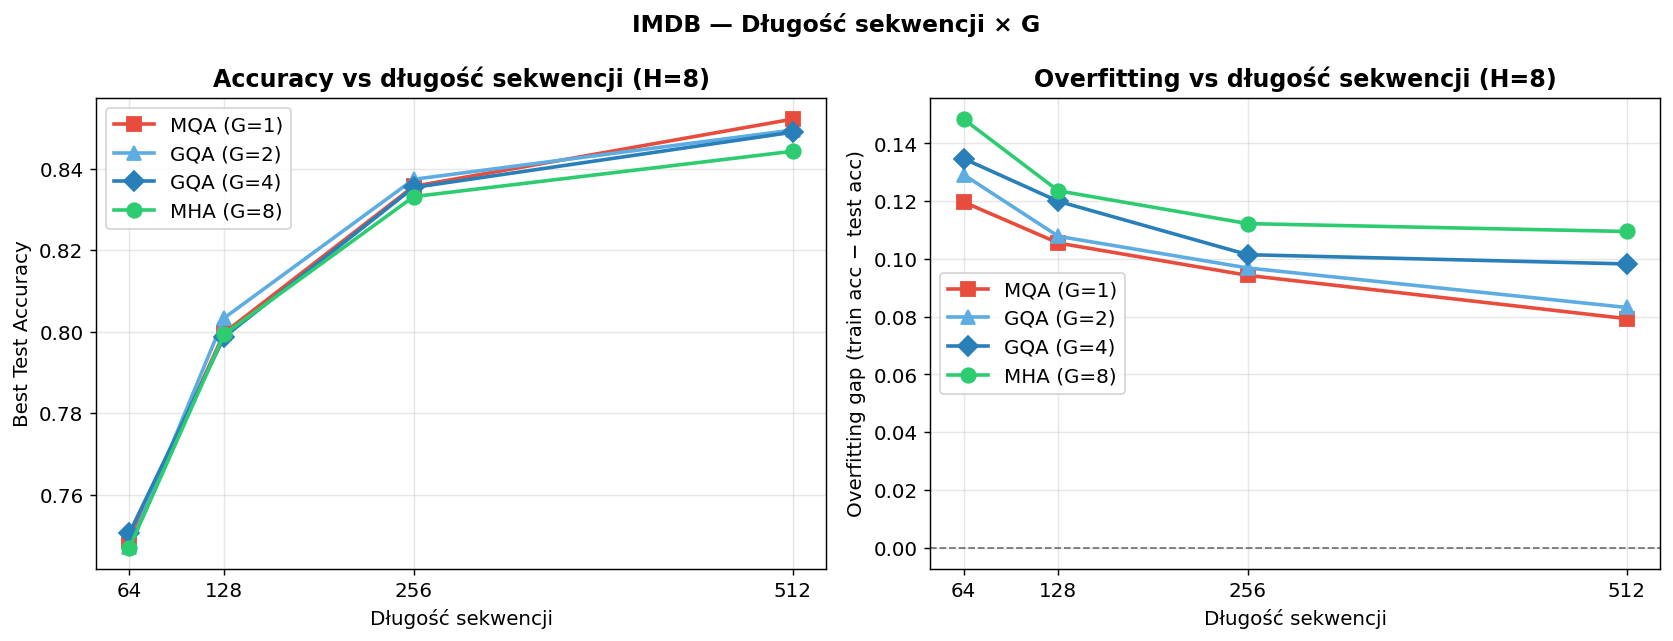

,MQA (G=1),GQA (G=2),GQA (G=4),MHA (G=8)
max_length,,,,
64,0.748700,0.747200,0.750700,0.747100
128,0.799800,0.803400,0.798800,0.799400
256,0.835700,0.837400,0.835400,0.833200
512,0.852200,0.849500,0.849000,0.844300


,MQA (G=1),GQA (G=2),GQA (G=4),MHA (G=8)
max_length,,,,
64,0.119700,0.129200,0.134800,0.148400
128,0.105500,0.107800,0.120000,0.123600
256,0.094300,0.096900,0.101500,0.112200
512,0.079300,0.083200,0.098300,0.109500


In [23]:
exp2 = df_imdb[df_imdb['run_name'].str.startswith('exp2_')].copy()

lengths = sorted(exp2['max_length'].dropna().unique().astype(int))
G_exp2  = sorted(exp2['num_groups'].dropna().unique().astype(int))

g_labels = {1: 'MQA (G=1)', 2: 'GQA (G=2)', 4: 'GQA (G=4)', 8: 'MHA (G=8)'}
g_colors = {1: COLORS['MQA'], 2: '#5dade2', 4: '#2980b9', 8: COLORS['MHA']}
g_markers = {1: 's', 2: '^', 4: 'D', 8: 'o'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for G in G_exp2:
    accs = [exp2[(exp2['max_length'] == L) & (exp2['num_groups'] == G)]['best_test_acc'].mean()
            for L in lengths]
    ax1.plot(lengths, accs,
             marker=g_markers[G], color=g_colors[G], linewidth=2, markersize=8,
             label=g_labels[G])

ax1.set_xlabel('Długość sekwencji')
ax1.set_ylabel('Best Test Accuracy')
ax1.set_title('Accuracy vs długość sekwencji (H=8)', fontweight='bold')
ax1.set_xticks(lengths)
ax1.legend()
ax1.grid(True, alpha=0.3)

for G in G_exp2:
    ovfts = [exp2[(exp2['max_length'] == L) & (exp2['num_groups'] == G)]['overfitting_gap'].mean()
             for L in lengths]
    ax2.plot(lengths, ovfts,
             marker=g_markers[G], color=g_colors[G], linewidth=2, markersize=8,
             label=g_labels[G])

ax2.set_xlabel('Długość sekwencji')
ax2.set_ylabel('Overfitting gap (train acc − test acc)')
ax2.set_title('Overfitting vs długość sekwencji (H=8)', fontweight='bold')
ax2.set_xticks(lengths)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('IMDB — Długość sekwencji × G', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_imdb_exp2.png', dpi=150, bbox_inches='tight')
plt.show()

tab_acc = (exp2.groupby(['max_length', 'num_groups'])['best_test_acc']
           .mean().unstack('num_groups').round(4))
tab_acc.columns = [g_labels.get(int(g), f'G={int(g)}') for g in tab_acc.columns]
tab_acc.index.name = 'max_length'

tab_ovft = (exp2.groupby(['max_length', 'num_groups'])['overfitting_gap']
            .mean().unstack('num_groups').round(4))
tab_ovft.columns = [g_labels.get(int(g), f'G={int(g)}') for g in tab_ovft.columns]
tab_ovft.index.name = 'max_length'

display(tab_acc.style.set_caption('Best Test Accuracy — długość sekwencji × G'))
display(tab_ovft.style.set_caption('Overfitting gap — długość sekwencji × G'))

---
## IMDB — Eksperyment 3: Layer-wise GQA

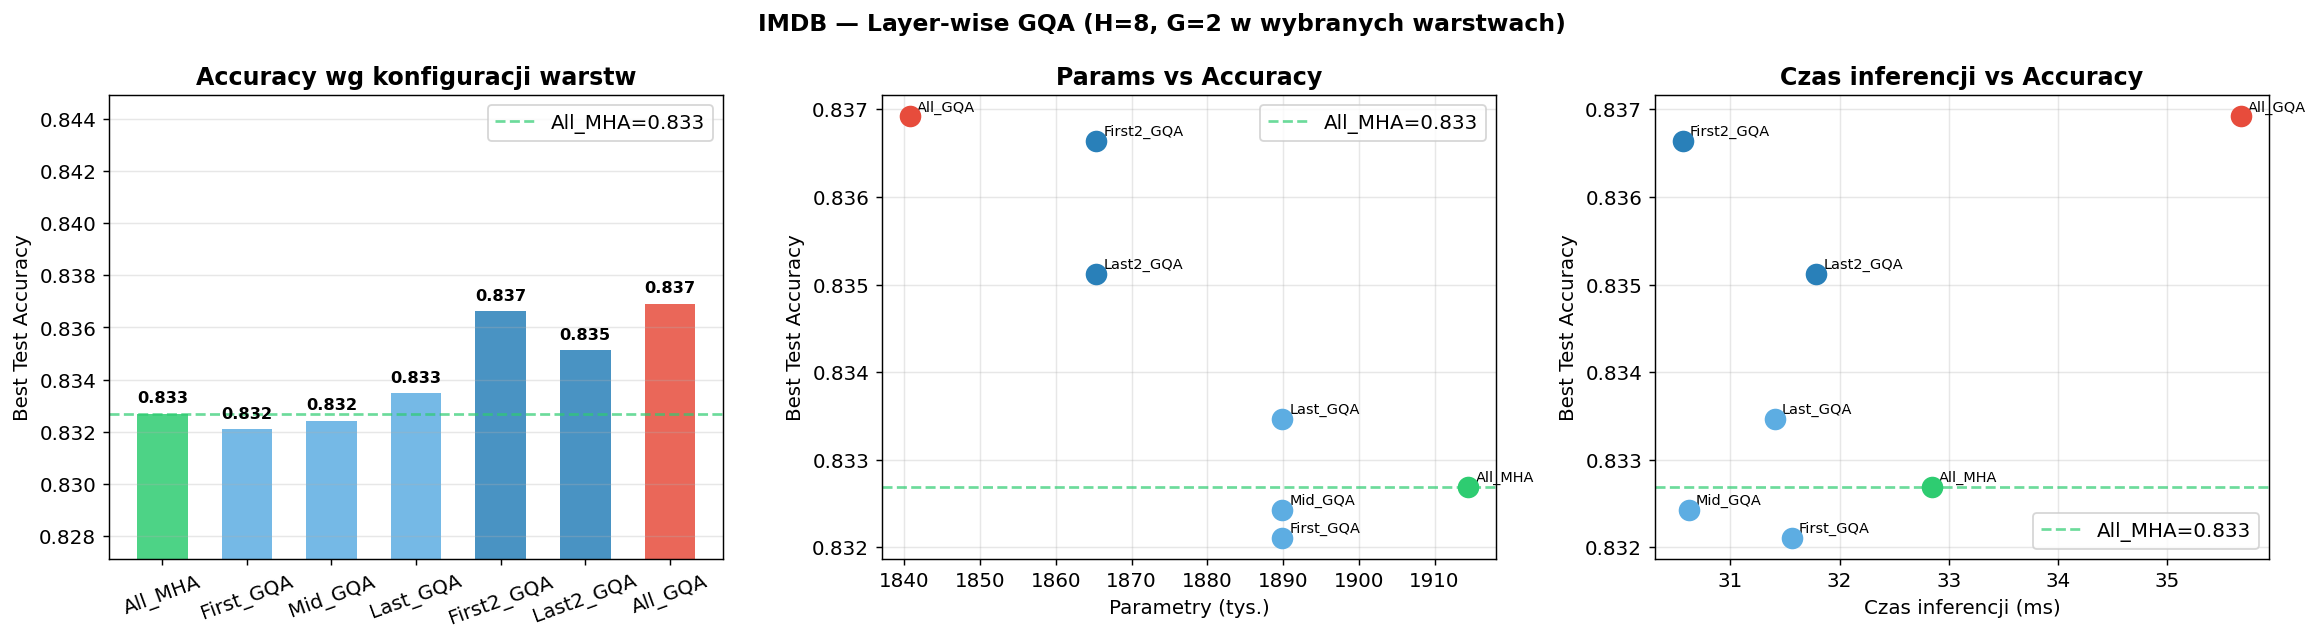

,acc,delta_vs_mha,params_k,inf_ms
config,,,,
All_MHA,0.832693,0.000000,1914,32.84
First_GQA,0.832107,-0.000587,1889,31.56
Mid_GQA,0.832427,-0.000267,1889,30.62
Last_GQA,0.833467,0.000773,1889,31.41
First2_GQA,0.836640,0.003947,1865,30.56
Last2_GQA,0.835120,0.002427,1865,31.79
All_GQA,0.836920,0.004227,1840,35.68


In [24]:
exp3 = df_imdb[df_imdb['run_name'].str.startswith('exp3_')].copy()

CFG_ORDER = ['All_MHA', 'First_GQA', 'Mid_GQA', 'Last_GQA', 'First2_GQA', 'Last2_GQA', 'All_GQA']
N_GQA     = {'All_MHA': 0, 'First_GQA': 1, 'Mid_GQA': 1, 'Last_GQA': 1,
             'First2_GQA': 2, 'Last2_GQA': 2, 'All_GQA': 3}
CFG_COLORS = {0: COLORS['MHA'], 1: '#5dade2', 2: '#2980b9', 3: '#e74c3c'}

summary3 = exp3.groupby('config').agg(
    acc    = ('best_test_acc', 'mean'),
    params = ('num_params', 'first'),
    inf_ms = ('inference_time_ms', 'mean'),
).reindex(CFG_ORDER)
ref_mha = summary3.loc['All_MHA', 'acc']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Bar chart ---
cfgs       = summary3.index.tolist()
accs       = summary3['acc'].values
colors_bar = [CFG_COLORS[N_GQA[c]] for c in cfgs]

bars = ax1.bar(cfgs, accs, color=colors_bar, alpha=0.85, width=0.6)
ax1.axhline(ref_mha, color=COLORS['MHA'], linestyle='--', linewidth=1.5,
            alpha=0.7, label=f'All_MHA={ref_mha:.3f}')
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylabel('Best Test Accuracy')
ax1.set_title('Accuracy wg konfiguracji warstw', fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()
ax1.set_ylim(accs.min() - 0.005, accs.max() + 0.008)

# --- 2. Params vs Accuracy ---
for cfg, acc, params in zip(cfgs, accs, summary3['params'].values):
    n = N_GQA[cfg]
    ax2.scatter(params / 1000, acc, s=120, color=CFG_COLORS[n], zorder=5)
    ax2.annotate(cfg, (params / 1000, acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)
ax2.axhline(ref_mha, color=COLORS['MHA'], linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'All_MHA={ref_mha:.3f}')
ax2.set_xlabel('Parametry (tys.)'); ax2.set_ylabel('Best Test Accuracy')
ax2.set_title('Params vs Accuracy', fontweight='bold')
ax2.grid(True, alpha=0.3); ax2.legend()

# --- 3. Czas inferencji vs Accuracy ---
for cfg, acc, inf_ms in zip(cfgs, accs, summary3['inf_ms'].values):
    n = N_GQA[cfg]
    ax3.scatter(inf_ms, acc, s=120, color=CFG_COLORS[n], zorder=5)
    ax3.annotate(cfg, (inf_ms, acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)
ax3.axhline(ref_mha, color=COLORS['MHA'], linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'All_MHA={ref_mha:.3f}')
ax3.set_xlabel('Czas inferencji (ms)'); ax3.set_ylabel('Best Test Accuracy')
ax3.set_title('Czas inferencji vs Accuracy', fontweight='bold')
ax3.grid(True, alpha=0.3); ax3.legend()

plt.suptitle('IMDB — Layer-wise GQA (H=8, G=2 w wybranych warstwach)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_imdb_exp3.png', dpi=150, bbox_inches='tight')
plt.show()

out3 = summary3.copy()
out3['delta_vs_mha'] = (out3['acc'] - ref_mha).round(6)
out3['params_k']     = (out3['params'] // 1000).astype(int)
display(out3[['acc','delta_vs_mha','params_k','inf_ms']].round({'acc':6,'inf_ms':2}))

---
## InsectWingbeat — Eksperyment 1: Siatka H×G

In [25]:
ins_grid = df_ins[df_ins['run_name'].str.startswith('grid_')].copy()

ins_summary = ins_grid.groupby(['num_heads', 'num_groups', 'attention_type']).agg(
    acc    = ('best_test_acc', 'mean'),
    ovft   = ('overfitting_gap', 'mean'),
    params = ('num_params', 'first'),
    inf_ms = ('inference_time_ms', 'mean'),
    avg_epoch_time_s = ('avg_epoch_time_s', 'mean'),
).reset_index()

display(ins_summary[['num_heads','num_groups','attention_type','acc','ovft','params','inf_ms', 'avg_epoch_time_s']]
        .sort_values('acc', ascending=False).reset_index(drop=True))

,num_heads,num_groups,attention_type,acc,ovft,params,inf_ms,avg_epoch_time_s
0,8,8,MHA,0.670667,-0.010583,165994,15.160395,38.816396
1,8,4,GQA,0.657567,-0.016050,153706,16.431175,37.448323
2,8,2,GQA,0.656033,-0.018675,147562,14.432498,35.408032
3,4,4,MHA,0.651200,-0.011175,165994,11.083285,26.178389
4,4,2,GQA,0.649200,-0.011150,153706,11.426485,26.125579
5,2,2,MHA,0.645833,-0.015358,165994,7.916760,17.577650
6,2,1,MQA,0.644067,-0.015900,153706,7.588799,16.952782
7,8,1,MQA,0.643667,-0.016633,144490,14.861978,35.362814
8,4,1,MQA,0.641933,-0.021583,147562,10.820755,24.200836
9,1,1,MHA,0.639600,-0.011508,165994,7.346069,15.020165


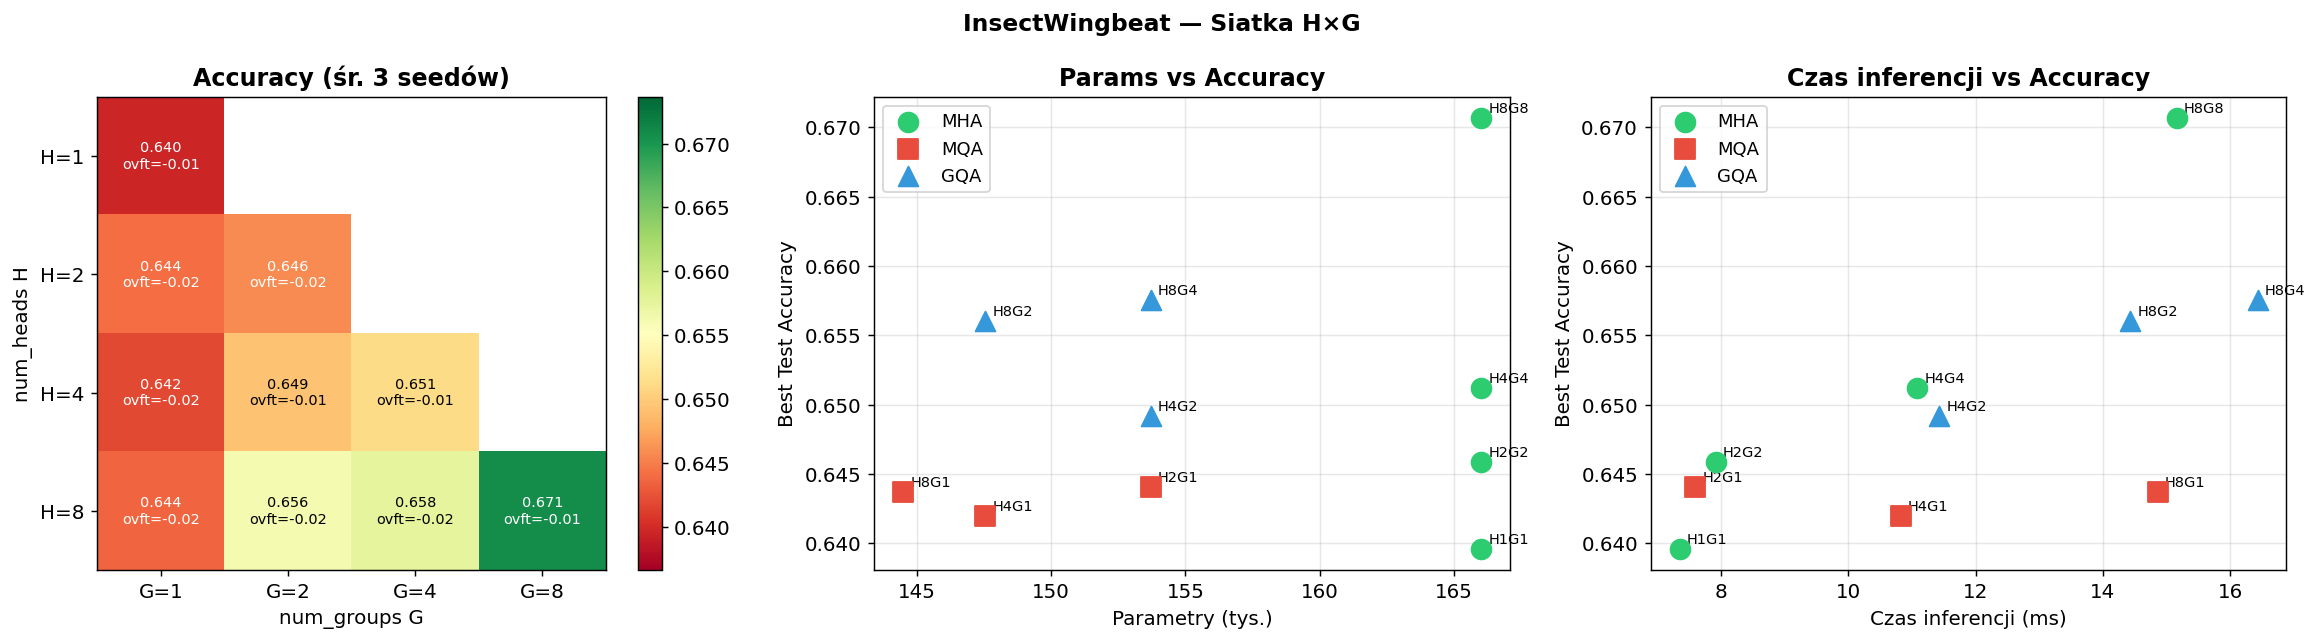

,num_heads,num_groups,attention_type,acc,ovft,params,inf_ms,avg_epoch_time_s
0,8,8,MHA,0.670667,-0.010583,165994,15.160395,38.816396
1,8,4,GQA,0.657567,-0.016050,153706,16.431175,37.448323
2,8,2,GQA,0.656033,-0.018675,147562,14.432498,35.408032
3,4,4,MHA,0.651200,-0.011175,165994,11.083285,26.178389
4,4,2,GQA,0.649200,-0.011150,153706,11.426485,26.125579
5,2,2,MHA,0.645833,-0.015358,165994,7.916760,17.577650
6,2,1,MQA,0.644067,-0.015900,153706,7.588799,16.952782
7,8,1,MQA,0.643667,-0.016633,144490,14.861978,35.362814
8,4,1,MQA,0.641933,-0.021583,147562,10.820755,24.200836
9,1,1,MHA,0.639600,-0.011508,165994,7.346069,15.020165


In [26]:
H_vals_i = sorted(ins_grid['num_heads'].dropna().unique().astype(int))
G_vals_i = sorted(ins_grid['num_groups'].dropna().unique().astype(int))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Heatmapa accuracy ---
mat_i      = np.full((len(H_vals_i), len(G_vals_i)), np.nan)
mat_ovft_i = np.full((len(H_vals_i), len(G_vals_i)), np.nan)

for _, row in ins_summary.iterrows():
    i = H_vals_i.index(int(row.num_heads))
    j = G_vals_i.index(int(row.num_groups))
    mat_i[i, j]      = row.acc
    mat_ovft_i[i, j] = row.ovft

vmin_i, vmax_i = np.nanmin(mat_i) - 0.003, np.nanmax(mat_i) + 0.003
im = ax1.imshow(mat_i, cmap='RdYlGn', vmin=vmin_i, vmax=vmax_i, aspect='auto')
ax1.set_xticks(range(len(G_vals_i))); ax1.set_xticklabels([f'G={g}' for g in G_vals_i])
ax1.set_yticks(range(len(H_vals_i))); ax1.set_yticklabels([f'H={h}' for h in H_vals_i])
ax1.set_title('Accuracy (śr. 3 seedów)', fontweight='bold')
ax1.set_xlabel('num_groups G'); ax1.set_ylabel('num_heads H')
plt.colorbar(im, ax=ax1, format='%.3f')

for i in range(len(H_vals_i)):
    for j in range(len(G_vals_i)):
        v = mat_i[i, j]
        if not np.isnan(v):
            rel = (v - vmin_i) / (vmax_i - vmin_i)
            clr = 'black' if 0.25 < rel < 0.75 else 'white'
            ovft_str = f'\novft={mat_ovft_i[i,j]:.2f}' if not np.isnan(mat_ovft_i[i,j]) else ''
            ax1.text(j, i, f'{v:.3f}{ovft_str}', ha='center', va='center', fontsize=8, color=clr)

# --- 2. Params vs Accuracy ---
for _, row in ins_summary.iterrows():
    at = row.attention_type
    marker = 'o' if at == 'MHA' else ('s' if at == 'MQA' else '^')
    ax2.scatter(row.params / 1000, row.acc, s=120, marker=marker,
                color=COLORS.get(at, 'gray'), zorder=5, label=at)
    ax2.annotate(f'H{int(row.num_heads)}G{int(row.num_groups)}',
                 (row.params / 1000, row.acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)

ax2.set_xlabel('Parametry (tys.)'); ax2.set_ylabel('Best Test Accuracy')
ax2.set_title('Params vs Accuracy', fontweight='bold')
ax2.grid(True, alpha=0.3)
handles, labels = ax2.get_legend_handles_labels()
seen = {}; uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen: seen[l] = True; uniq_h.append(h); uniq_l.append(l)
ax2.legend(uniq_h, uniq_l, fontsize=10)

# --- 3. Czas inferencji vs Accuracy ---
for _, row in ins_summary.iterrows():
    at = row.attention_type
    marker = 'o' if at == 'MHA' else ('s' if at == 'MQA' else '^')
    ax3.scatter(row.inf_ms, row.acc, s=120, marker=marker,
                color=COLORS.get(at, 'gray'), zorder=5, label=at)
    ax3.annotate(f'H{int(row.num_heads)}G{int(row.num_groups)}',
                 (row.inf_ms, row.acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)

ax3.set_xlabel('Czas inferencji (ms)'); ax3.set_ylabel('Best Test Accuracy')
ax3.set_title('Czas inferencji vs Accuracy', fontweight='bold')
ax3.grid(True, alpha=0.3)
handles, labels = ax3.get_legend_handles_labels()
seen = {}; uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen: seen[l] = True; uniq_h.append(h); uniq_l.append(l)
ax3.legend(uniq_h, uniq_l, fontsize=10)

plt.suptitle('InsectWingbeat — Siatka H×G', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_insect_exp1.png', dpi=150, bbox_inches='tight')
plt.show()

display(ins_summary[['num_heads','num_groups','attention_type','acc','ovft','params','inf_ms', 'avg_epoch_time_s']]
        .sort_values('acc', ascending=False).reset_index(drop=True))

---
## InsectWingbeat — Eksperyment 2: Naive GQA vs Dynamic GQA

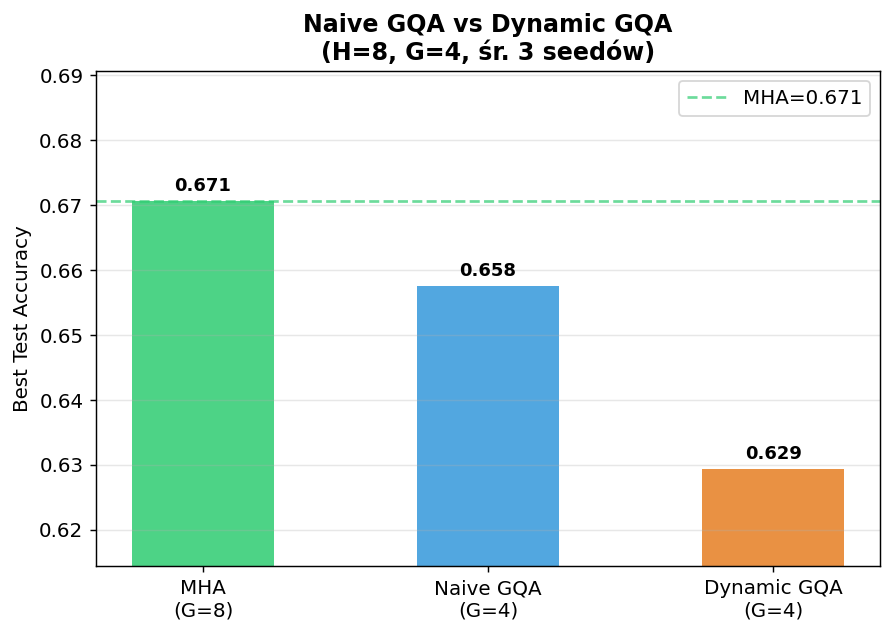

,mean_acc,delta_vs_mha
wariant,,
MHA (G=8),0.670667,0.0000
Naive GQA (G=4),0.657567,-0.0131
Dynamic GQA (G=4),0.629367,-0.0413


,run_name,best_test_acc,overfitting_gap
0,grid_H8_G8_seed777,0.6728,-0.017375
1,grid_H8_G8_seed123,0.6655,-0.005875
2,grid_H8_G8_seed42,0.6737,-0.008500
3,grid_H8_G4_seed777,0.6466,-0.012775
4,grid_H8_G4_seed123,0.6623,-0.015400
5,grid_H8_G4_seed42,0.6638,-0.019975
6,dynamic_H8_G4_seed777,0.6016,NaN
7,dynamic_H8_G4_seed123,0.6390,NaN
8,dynamic_H8_G4_seed42,0.6475,NaN


In [36]:
dyn        = df_ins[df_ins['run_name'].str.startswith('dynamic_')].copy()
naive_h8g4 = ins_grid[(ins_grid['num_heads'] == 8) & (ins_grid['num_groups'] == 4)].copy()
mha_h8g8   = ins_grid[(ins_grid['num_heads'] == 8) & (ins_grid['num_groups'] == 8)].copy()

labels = ['MHA\n(G=8)', 'Naive GQA\n(G=4)', 'Dynamic GQA\n(G=4)']
means  = [mha_h8g8['best_test_acc'].mean(),
          naive_h8g4['best_test_acc'].mean(),
          dyn['best_test_acc'].mean()]
colors = [COLORS['MHA'], COLORS['GQA'], COLORS['DynamicGQA']]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, means, color=colors, alpha=0.85, width=0.5)
ax.axhline(means[0], color=COLORS['MHA'], linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'MHA={means[0]:.3f}')

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{m:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Best Test Accuracy')
ax.set_title('Naive GQA vs Dynamic GQA\n(H=8, G=4, śr. 3 seedów)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
ax.set_ylim(min(means) - 0.015, max(means) + 0.02)

plt.tight_layout()
plt.savefig('wyniki_insect_exp2.png', dpi=150, bbox_inches='tight')
plt.show()

summary_exp2 = pd.DataFrame({
    'wariant':       ['MHA (G=8)', 'Naive GQA (G=4)', 'Dynamic GQA (G=4)'],
    'mean_acc':      [round(m, 6) for m in means],
    'delta_vs_mha':  [round(m - means[0], 6) for m in means],
}).set_index('wariant')
display(summary_exp2)

dyn_detail = dyn[['run_name', 'best_test_acc', 'overfitting_gap']].copy()
naive_detail = naive_h8g4[['run_name', 'best_test_acc', 'overfitting_gap']].copy()
mha_detail   = mha_h8g8[['run_name',  'best_test_acc', 'overfitting_gap']].copy()
display(pd.concat([mha_detail, naive_detail, dyn_detail]).reset_index(drop=True))

In [ ]:
# Krzywe uczenia — Naive GQA vs Dynamic GQA (InsectWingbeat, H=8, G=4)
from mlflow.tracking import MlflowClient
client_lc = MlflowClient()

def _load_curves(run_ids, metric):
    arrays = [
        np.array([h.value for h in sorted(client_lc.get_metric_history(rid, metric), key=lambda x: x.step)])
        for rid in run_ids
    ]
    arr = np.array(arrays)
    return arr.mean(axis=0), arr.std(axis=0)

groups_lc = {
    'MHA (G=8)':       (mha_h8g8['run_id'].tolist(),   COLORS['MHA'],         'o'),
    'Naive GQA (G=4)': (naive_h8g4['run_id'].tolist(), COLORS['GQA'],         's'),
    'Dynamic GQA':     (dyn['run_id'].tolist(),         COLORS['DynamicGQA'],  '^'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rows_lc = []
for label, (rids, col, mk) in groups_lc.items():
    mean_tr, std_tr = _load_curves(rids, 'train_acc')
    mean_te, std_te = _load_curves(rids, 'test_acc')
    gap    = mean_tr - mean_te
    epochs = np.arange(1, len(mean_tr) + 1)

    axes[0].plot(epochs, mean_te, color=col, lw=2, marker=mk, markevery=5, markersize=7, label=label)
    axes[0].fill_between(epochs, mean_te - std_te, mean_te + std_te, alpha=0.15, color=col)
    axes[1].plot(epochs, mean_tr, color=col, lw=2, marker=mk, markevery=5, markersize=7, label=label)
    axes[1].fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, alpha=0.15, color=col)
    axes[2].plot(epochs, gap, color=col, lw=2, marker=mk, markevery=5, markersize=7, label=label)

    rows_lc.append({
        'wariant': label,
        'test_e5':    round(mean_te[4],  4) if len(mean_te) > 4  else None,
        'test_e10':   round(mean_te[9],  4) if len(mean_te) > 9  else None,
        'test_e15':   round(mean_te[14], 4) if len(mean_te) > 14 else None,
        'test_final': round(mean_te[-1], 4),
        'max_test':   round(mean_te.max(), 4),
        'best_epoch': int(mean_te.argmax() + 1),
    })

axes[0].set_title('Test Accuracy — zbieżność', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[1].set_title('Train Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[2].set_title('Overfitting gap (train − test)', fontweight='bold')
axes[2].set_ylabel('Gap')
axes[2].axhline(0, color='black', ls='--', alpha=0.4)
for ax in axes:
    ax.set_xlabel('Epoka'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('InsectWingbeat — Krzywe uczenia: Naive GQA vs Dynamic GQA (H=8, G=4, śr. 3 seedów)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_insect_naive_vs_dynamic_lc.png', dpi=150, bbox_inches='tight')
plt.show()

display(pd.DataFrame(rows_lc).set_index('wariant'))

In [35]:
print(mlflow.get_tracking_uri())


./mlruns


---
## InsectWingbeat — Eksperyment 3: Layer-wise GQA

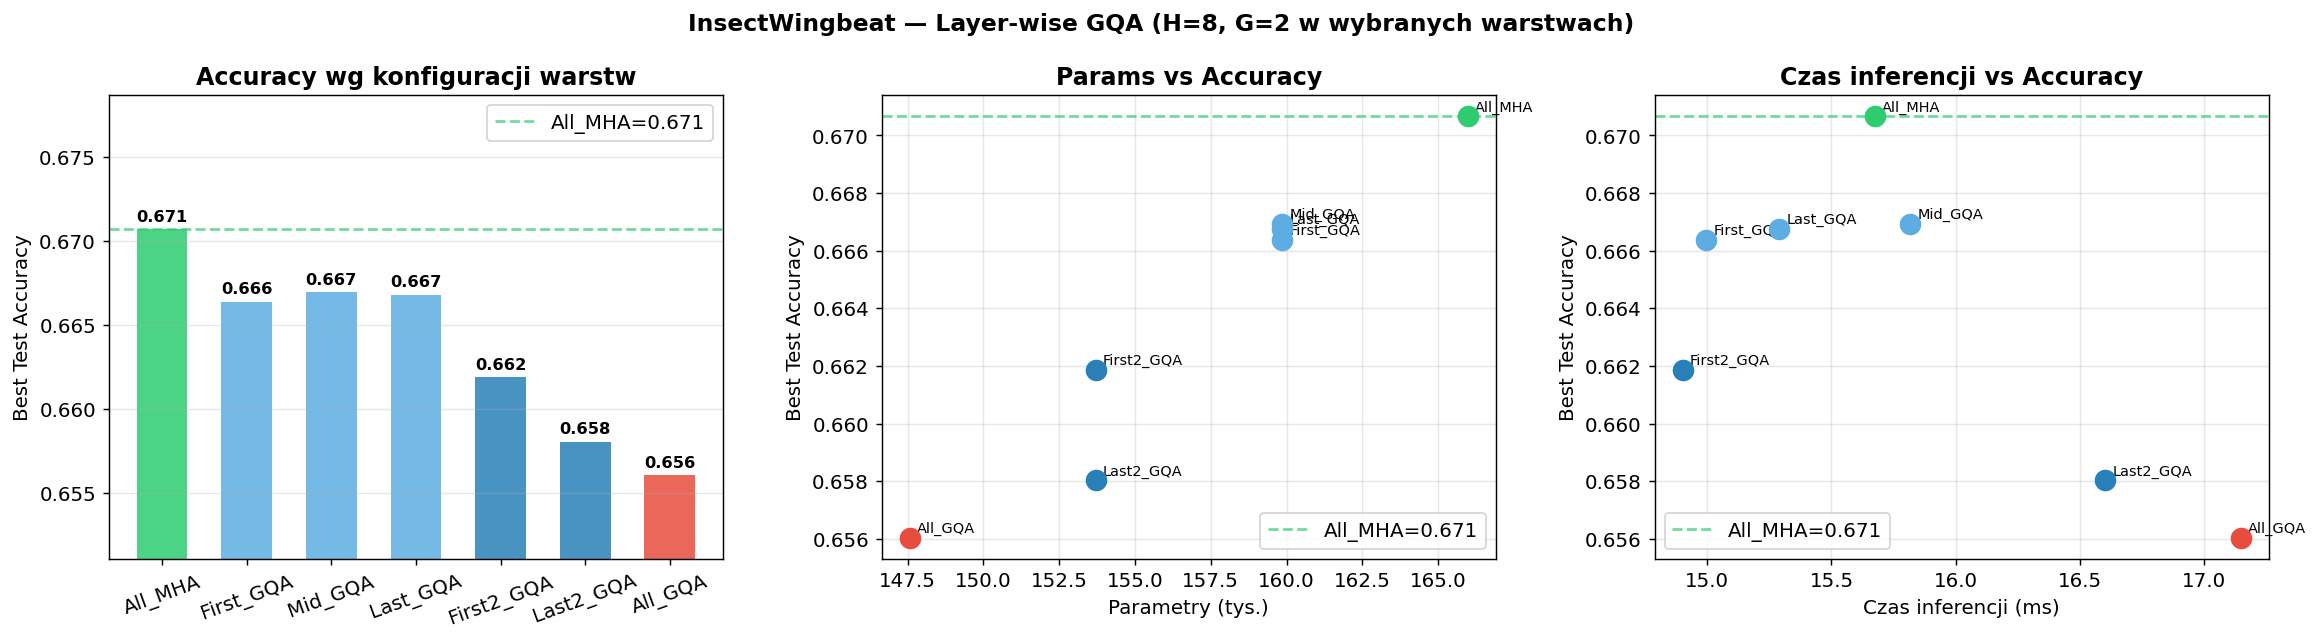

,acc,ovft,delta_vs_mha,params_k,inf_ms
config,,,,,
All_MHA,0.670667,-0.010583,0.000000,165,15.67
First_GQA,0.666367,-0.010200,-0.004300,159,15.00
Mid_GQA,0.666933,-0.015867,-0.003733,159,15.82
Last_GQA,0.666767,-0.014508,-0.003900,159,15.29
First2_GQA,0.661867,-0.018667,-0.008800,153,14.90
Last2_GQA,0.658033,-0.015333,-0.012633,153,16.60
All_GQA,0.656033,-0.018675,-0.014633,147,17.15


In [28]:
ins_lw = df_ins[df_ins['run_name'].str.startswith('lw_')].copy()
for col in ['best_test_acc', 'overfitting_gap', 'num_params', 'inference_time_ms']:
    ins_lw[col] = pd.to_numeric(ins_lw[col], errors='coerce')

ins_lw['config'] = (ins_lw['run_name']
                    .str.replace(r'^lw_', '', regex=True)
                    .str.replace(r'_seed\d+$', '', regex=True))

CFG_ORDER_I = ['All_MHA', 'First_GQA', 'Mid_GQA', 'Last_GQA', 'First2_GQA', 'Last2_GQA', 'All_GQA']
N_GQA_I     = {'All_MHA': 0, 'First_GQA': 1, 'Mid_GQA': 1, 'Last_GQA': 1,
               'First2_GQA': 2, 'Last2_GQA': 2, 'All_GQA': 3}
CFG_COLORS_I = {0: COLORS['MHA'], 1: '#5dade2', 2: '#2980b9', 3: '#e74c3c'}

ins_sum3 = ins_lw.groupby('config').agg(
    acc    = ('best_test_acc', 'mean'),
    ovft   = ('overfitting_gap', 'mean'),
    params = ('num_params', 'first'),
    inf_ms = ('inference_time_ms', 'mean'),
).reindex(CFG_ORDER_I)
ref_mha_i = ins_sum3.loc['All_MHA', 'acc']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

cfgs_i     = ins_sum3.index.tolist()
accs_i     = ins_sum3['acc'].values
colors_i   = [CFG_COLORS_I[N_GQA_I[c]] for c in cfgs_i]

# --- 1. Bar chart ---
bars = ax1.bar(cfgs_i, accs_i, color=colors_i, alpha=0.85, width=0.6)
ax1.axhline(ref_mha_i, color=COLORS['MHA'], linestyle='--', linewidth=1.5,
            alpha=0.7, label=f'All_MHA={ref_mha_i:.3f}')
for bar, acc in zip(bars, accs_i):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylabel('Best Test Accuracy')
ax1.set_title('Accuracy wg konfiguracji warstw', fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()
ax1.set_ylim(accs_i.min() - 0.005, accs_i.max() + 0.008)

# --- 2. Params vs Accuracy ---
for cfg, acc, params in zip(cfgs_i, accs_i, ins_sum3['params'].values):
    n = N_GQA_I[cfg]
    ax2.scatter(params / 1000, acc, s=120, color=CFG_COLORS_I[n], zorder=5)
    ax2.annotate(cfg, (params / 1000, acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)
ax2.axhline(ref_mha_i, color=COLORS['MHA'], linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'All_MHA={ref_mha_i:.3f}')
ax2.set_xlabel('Parametry (tys.)'); ax2.set_ylabel('Best Test Accuracy')
ax2.set_title('Params vs Accuracy', fontweight='bold')
ax2.grid(True, alpha=0.3); ax2.legend()

# --- 3. Czas inferencji vs Accuracy ---
for cfg, acc, inf_ms in zip(cfgs_i, accs_i, ins_sum3['inf_ms'].values):
    n = N_GQA_I[cfg]
    ax3.scatter(inf_ms, acc, s=120, color=CFG_COLORS_I[n], zorder=5)
    ax3.annotate(cfg, (inf_ms, acc), xytext=(4, 3),
                 textcoords='offset points', fontsize=8)
ax3.axhline(ref_mha_i, color=COLORS['MHA'], linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'All_MHA={ref_mha_i:.3f}')
ax3.set_xlabel('Czas inferencji (ms)'); ax3.set_ylabel('Best Test Accuracy')
ax3.set_title('Czas inferencji vs Accuracy', fontweight='bold')
ax3.grid(True, alpha=0.3); ax3.legend()

plt.suptitle('InsectWingbeat — Layer-wise GQA (H=8, G=2 w wybranych warstwach)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_insect_exp3.png', dpi=150, bbox_inches='tight')
plt.show()

out3i = ins_sum3.copy()
out3i['delta_vs_mha'] = (out3i['acc'] - ref_mha_i).round(6)
out3i['params_k']     = (out3i['params'] // 1000).astype(int)
display(out3i[['acc', 'ovft', 'delta_vs_mha', 'params_k', 'inf_ms']].round({'acc': 6, 'ovft': 6, 'inf_ms': 2}))

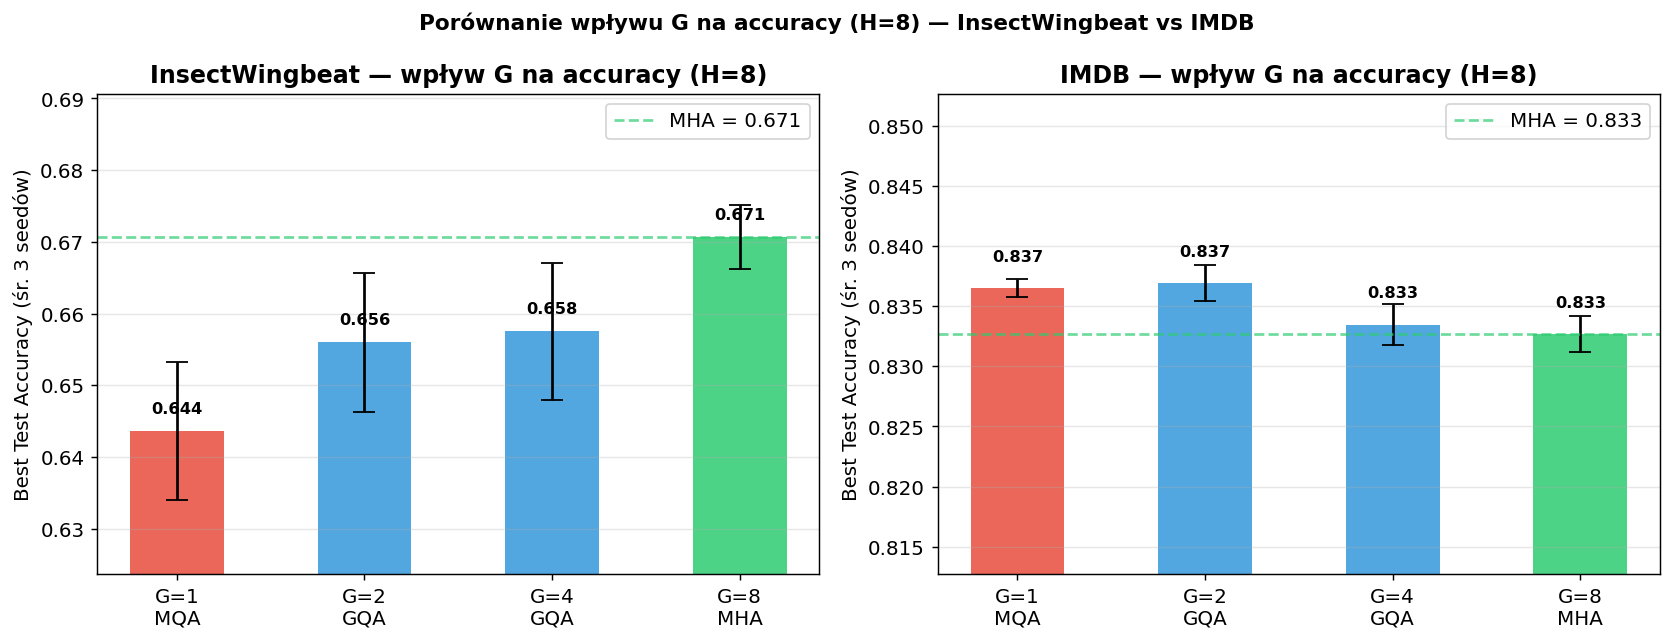

In [29]:
h8 = ins_summary[ins_summary['num_heads'] == 8].sort_values('num_groups')
h8_std = ins_grid[
    pd.to_numeric(ins_grid['num_heads'], errors='coerce') == 8
].groupby('num_groups')['best_test_acc'].std().reindex(h8['num_groups'].values)

h8_imdb_s = grid[grid['num_heads'] == 8].sort_values('num_groups')
h8_imdb_std = exp1[
    pd.to_numeric(exp1['num_heads'], errors='coerce') == 8
].groupby('num_groups')['best_test_acc'].std().reindex(h8_imdb_s['num_groups'].values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, std, title in [
    (axes[0], h8,        h8_std,       'InsectWingbeat'),
    (axes[1], h8_imdb_s, h8_imdb_std,  'IMDB'),
]:
    labels = [f'G={int(g)}\n{"MHA" if g==data["num_groups"].max() else ("MQA" if g==1 else "GQA")}'
              for g in data['num_groups'].values]
    colors = [COLORS.get(t, '#3498db') for t in data['attention_type'].values]
    bars = ax.bar(labels, data['acc'].values, yerr=std.values,
                  color=colors, alpha=0.85, capsize=6, width=0.5)
    mha = data[data['num_groups'] == data['num_groups'].max()]['acc'].values[0]
    ax.axhline(mha, color=COLORS['MHA'], linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'MHA = {mha:.3f}')
    for bar, acc in zip(bars, data['acc'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel('Best Test Accuracy (śr. 3 seedów)')
    ax.set_title(f'{title} — wpływ G na accuracy (H=8)', fontweight='bold')
    ax.set_ylim(data['acc'].min() - 0.02, mha + 0.02)
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Porównanie wpływu G na accuracy (H=8) — InsectWingbeat vs IMDB',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_trend_G_porownanie.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Krzywe uczenia — zbieżność per epoka (z MLflow history)

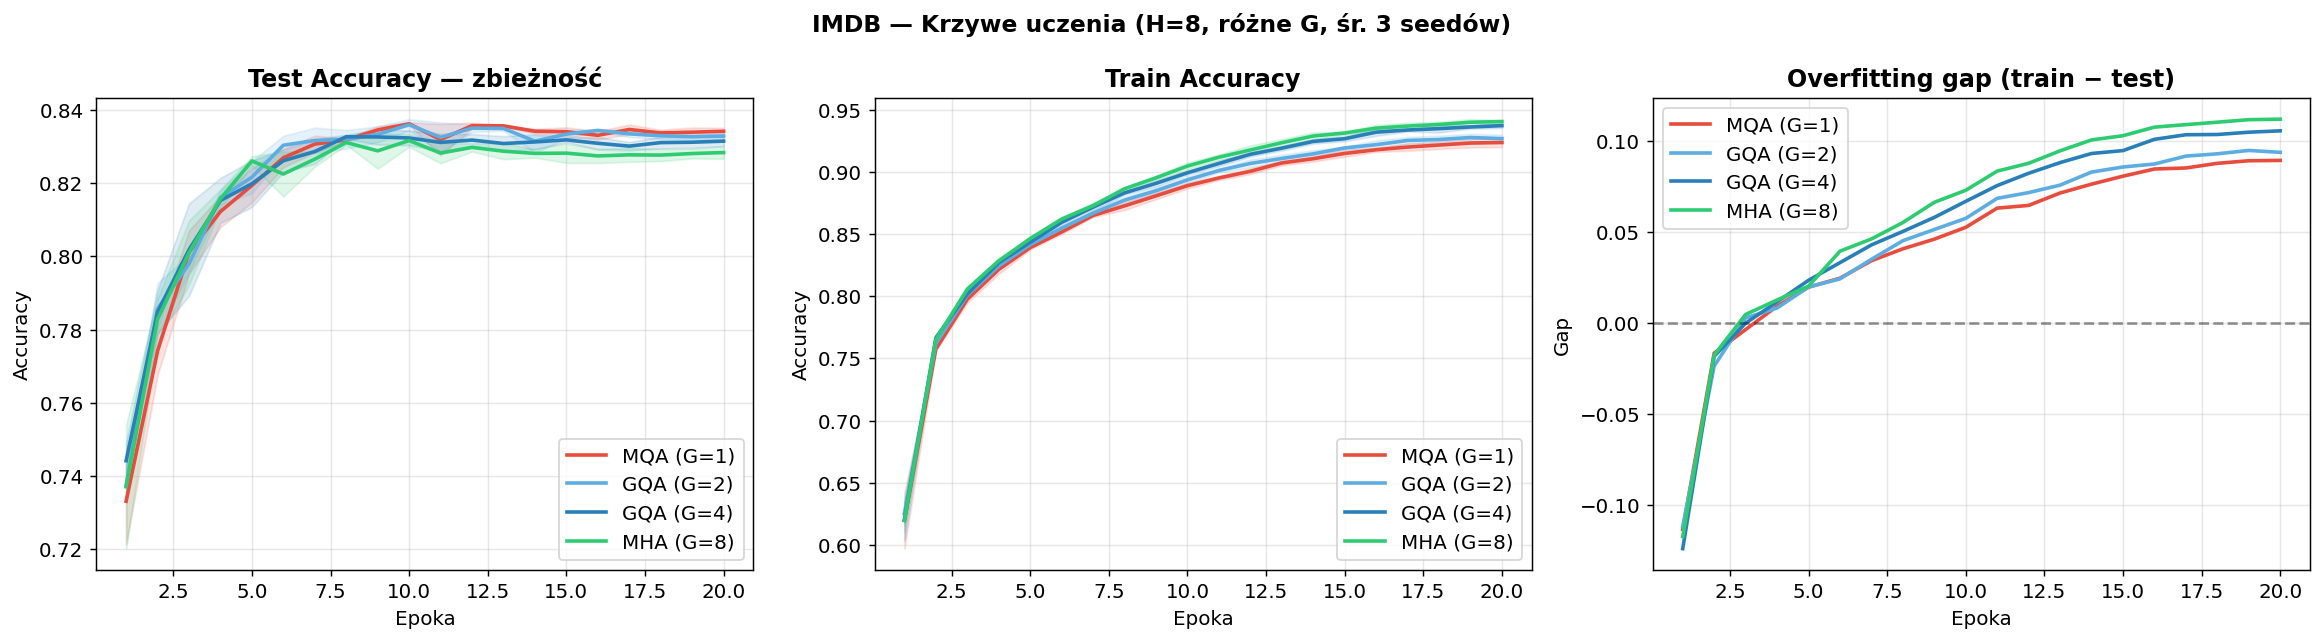

,typ,test_e5,test_e10,test_e15,test_e20,max_test,best_epoch
G,,,,,,,
1,MQA (G=1),0.8194,0.8363,0.8341,0.8342,0.8363,10
2,GQA (G=2),0.8217,0.8360,0.8334,0.8329,0.8360,10
4,GQA (G=4),0.8199,0.8324,0.8319,0.8315,0.8327,8
8,MHA (G=8),0.8261,0.8317,0.8282,0.8284,0.8317,10


In [30]:
from mlflow.tracking import MlflowClient
from IPython.display import display
client = MlflowClient()

def load_curves_mean(run_ids, metric):
    arrays = [
        np.array([h.value for h in sorted(client.get_metric_history(rid, metric), key=lambda x: x.step)])
        for rid in run_ids
    ]
    arr = np.array(arrays)
    return arr.mean(axis=0), arr.std(axis=0)

# H=8, grid runs IMDB
h8_imdb = df_imdb[
    df_imdb['run_name'].str.startswith('grid_') &
    (pd.to_numeric(df_imdb['num_heads'], errors='coerce') == 8)
].copy()
h8_imdb['num_groups'] = pd.to_numeric(h8_imdb['num_groups'])

G_lc      = sorted(h8_imdb['num_groups'].unique().astype(int))
g_col_lc  = {1: COLORS['MQA'], 2: '#5dade2', 4: '#2980b9', 8: COLORS['MHA']}
g_lbl_lc  = {1: 'MQA (G=1)', 2: 'GQA (G=2)', 4: 'GQA (G=4)', 8: 'MHA (G=8)'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rows = []
for G in G_lc:
    rids = h8_imdb[h8_imdb['num_groups'] == G]['run_id'].tolist()
    mean_tr, std_tr = load_curves_mean(rids, 'train_acc')
    mean_te, std_te = load_curves_mean(rids, 'test_acc')
    gap    = mean_tr - mean_te
    epochs = np.arange(1, len(mean_tr) + 1)
    col, lbl = g_col_lc[G], g_lbl_lc[G]

    axes[0].plot(epochs, mean_te, color=col, lw=2, label=lbl)
    axes[0].fill_between(epochs, mean_te - std_te, mean_te + std_te, alpha=0.15, color=col)
    axes[1].plot(epochs, mean_tr, color=col, lw=2, label=lbl)
    axes[1].fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, alpha=0.15, color=col)
    axes[2].plot(epochs, gap, color=col, lw=2, label=lbl)

    rows.append({
        'G': G, 'typ': g_lbl_lc[G],
        'test_e5':  round(mean_te[4],  4),
        'test_e10': round(mean_te[9],  4),
        'test_e15': round(mean_te[14], 4),
        'test_e20': round(mean_te[-1], 4),
        'max_test': round(mean_te.max(), 4),
        'best_epoch': int(mean_te.argmax() + 1),
    })

axes[0].set_title('Test Accuracy — zbieżność', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[1].set_title('Train Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[2].set_title('Overfitting gap (train − test)', fontweight='bold')
axes[2].set_ylabel('Gap')
axes[2].axhline(0, color='black', ls='--', alpha=0.4)
for ax in axes:
    ax.set_xlabel('Epoka'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('IMDB — Krzywe uczenia (H=8, różne G, śr. 3 seedów)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_imdb_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

display(pd.DataFrame(rows).set_index('G'))

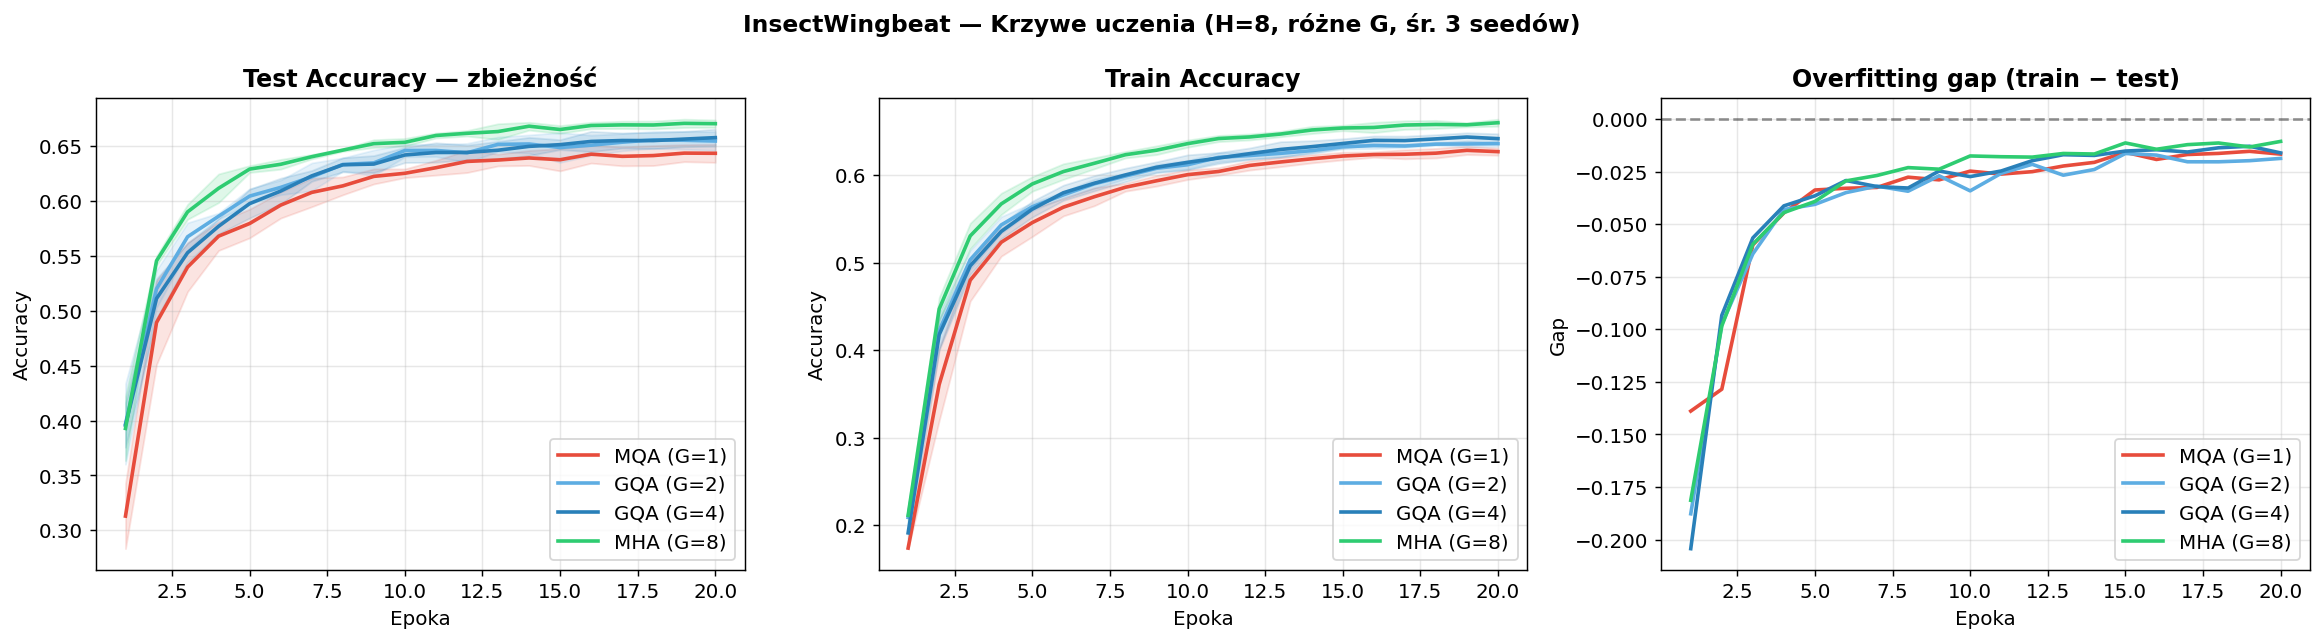

,typ,test_e5,test_e10,test_e15,test_e20,max_test,best_epoch
G,,,,,,,
1,MQA (G=1),0.5794,0.6251,0.6374,0.6433,0.6435,19
2,GQA (G=2),0.6043,0.6458,0.6486,0.6545,0.6555,18
4,GQA (G=4),0.5975,0.6418,0.6512,0.6576,0.6576,20
8,MHA (G=8),0.6289,0.6533,0.6650,0.6703,0.6706,19


In [31]:
# InsectWingbeat — krzywe uczenia H=8
h8_ins = df_ins[
    df_ins['run_name'].str.startswith('grid_') &
    (pd.to_numeric(df_ins['num_heads'], errors='coerce') == 8)
].copy()
h8_ins['num_groups'] = pd.to_numeric(h8_ins['num_groups'])

G_lc_i = sorted(h8_ins['num_groups'].unique().astype(int))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rows_i = []
for G in G_lc_i:
    rids = h8_ins[h8_ins['num_groups'] == G]['run_id'].tolist()
    mean_tr, std_tr = load_curves_mean(rids, 'train_acc')
    mean_te, std_te = load_curves_mean(rids, 'test_acc')
    gap    = mean_tr - mean_te
    epochs = np.arange(1, len(mean_tr) + 1)
    col, lbl = g_col_lc[G], g_lbl_lc[G]

    axes[0].plot(epochs, mean_te, color=col, lw=2, label=lbl)
    axes[0].fill_between(epochs, mean_te - std_te, mean_te + std_te, alpha=0.15, color=col)
    axes[1].plot(epochs, mean_tr, color=col, lw=2, label=lbl)
    axes[1].fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, alpha=0.15, color=col)
    axes[2].plot(epochs, gap, color=col, lw=2, label=lbl)

    rows_i.append({
        'G': G, 'typ': g_lbl_lc[G],
        'test_e5':  round(mean_te[4],  4),
        'test_e10': round(mean_te[9],  4),
        'test_e15': round(mean_te[14], 4),
        'test_e20': round(mean_te[-1], 4),
        'max_test': round(mean_te.max(), 4),
        'best_epoch': int(mean_te.argmax() + 1),
    })

axes[0].set_title('Test Accuracy — zbieżność', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[1].set_title('Train Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[2].set_title('Overfitting gap (train − test)', fontweight='bold')
axes[2].set_ylabel('Gap')
axes[2].axhline(0, color='black', ls='--', alpha=0.4)
for ax in axes:
    ax.set_xlabel('Epoka'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('InsectWingbeat — Krzywe uczenia (H=8, różne G, śr. 3 seedów)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_insect_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

display(pd.DataFrame(rows_i).set_index('G'))